<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# Unsupervised Learning – Einfaches Clustering mit K-Means

In diesem Notebook schauen wir uns **Unsupervised Learning** am Beispiel von **K-Means-Clustering** an.

Ziele:

- verstehen, was Unsupervised Learning ist
- sehen, wie ein Algorithmus **ohne Labels** Gruppen in Daten findet
- visuell nachvollziehen, was K-Means macht


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

%matplotlib inline

## 1. Datenset erstellen (ohne Labels für das Modell)

Wir erzeugen mit `make_blobs` einen **künstlichen 2D-Datensatz** mit drei „natürlichen“ Gruppen (Blobs).

Für uns Menschen sind die Gruppen sichtbar – das Modell bekommt aber **keine Klassenlabels**, nur die Punkte.


In [2]:
# Zufallsdaten mit 3 Zentren erzeugen
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.80,
    random_state=42
)

X[:5]

array([[-7.24711591, -7.55998509],
       [-7.56795788, -7.18775403],
       [-1.85116169,  8.03761121],
       [ 4.46573387,  2.85219117],
       [-8.51012682, -7.68657864]])

## 2. Rohdaten visualisieren

Wir zeichnen die Punkte ohne Farben für Cluster – so sieht das Modell die Daten anfangs (ohne Wissen über Gruppen).


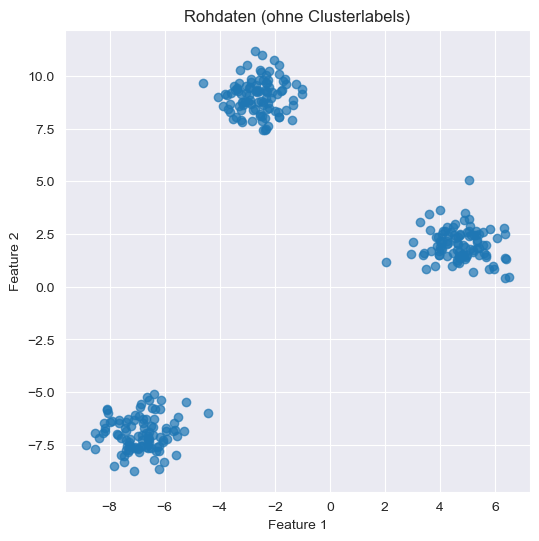

In [3]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Rohdaten (ohne Clusterlabels)")
plt.grid(True)
plt.show()

## 3. K-Means-Clustering anwenden

Wir sagen K-Means nur:

- **`n_clusters=3`** → finde 3 Gruppen
- aber wir geben **keine Labels** vor

Der Algorithmus:

1. startet mit zufälligen Clusterzentren  
2. ordnet jedem Punkt das nächste Zentrum zu  
3. berechnet neue Zentren aus den zugeordneten Punkten  
4. wiederholt das, bis sich nichts mehr groß ändert


In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X)

clusters[:10]

array([1, 1, 0, 2, 1, 2, 0, 2, 0, 0], dtype=int32)

## 4. Ergebnis visualisieren

Jetzt färben wir die Punkte nach den vom Modell gefundenen Clustern und zeichnen die Zentren ein.


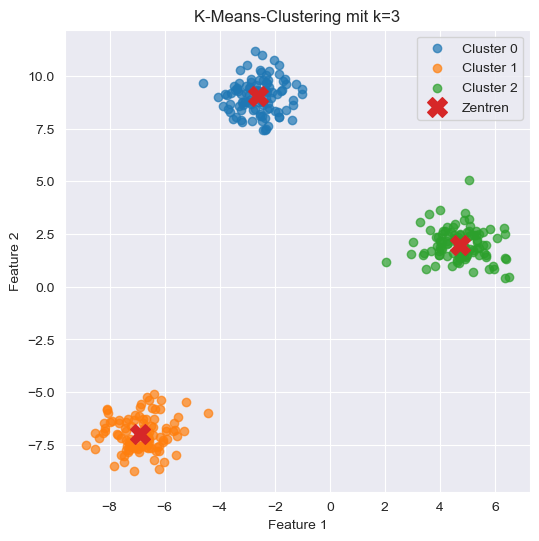

In [5]:
plt.figure(figsize=(6, 6))

for c in sorted(np.unique(clusters)):
    subset = X[clusters == c]
    plt.scatter(subset[:, 0], subset[:, 1], alpha=0.7, label=f"Cluster {c}")

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=200, label="Zentren")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means-Clustering mit k=3")
plt.legend()
plt.grid(True)
plt.show()

## 5. Was ist hier passiert?

Wichtig:

- Das Modell **kannte keine Labels** – nur die Punktkoordinaten.
- K-Means hat Gruppen gefunden, die **geometrisch sinnvoll** sind.
- Cluster-Nummern (0, 1, 2) sind **nur IDs**, sie haben keine „Bedeutung“ – sie könnten auch anders durchgemischt sein.

Das ist der Kern von **Unsupervised Learning**:

> Das Modell entdeckt Strukturen, ohne dass wir ihm sagen, was „richtig“ ist.


## 6. Bonus: verschiedene k-Werte ausprobieren

Was passiert, wenn wir **k** verändern?  
Wir probieren k = 2, 3, 4.


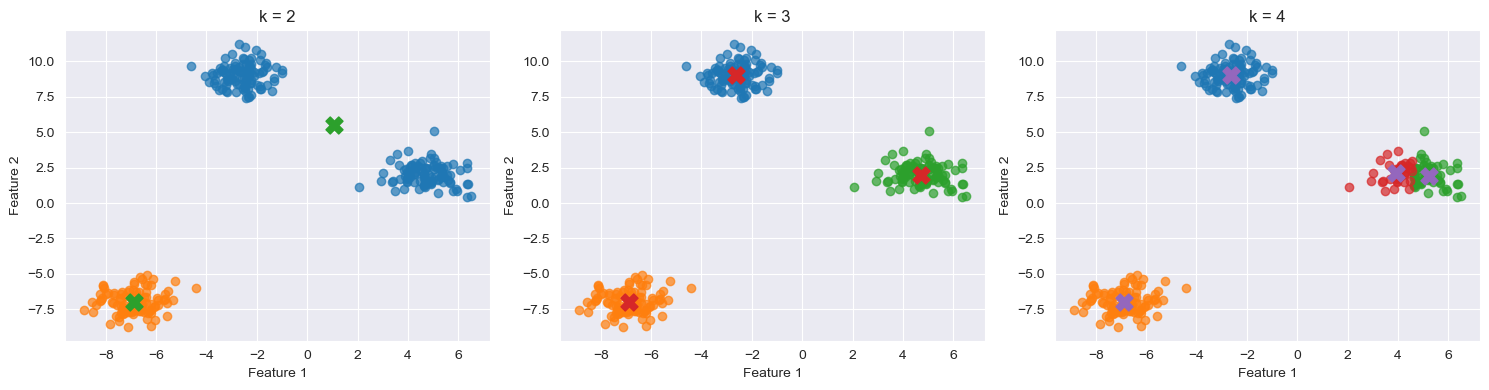

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, [2, 3, 4]):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cl = km.fit_predict(X)
    for c in sorted(np.unique(cl)):
        subset = X[cl == c]
        ax.scatter(subset[:, 0], subset[:, 1], alpha=0.7, label=f"Cluster {c}")
    centers = km.cluster_centers_
    ax.scatter(centers[:, 0], centers[:, 1], marker="X", s=150)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True)

plt.tight_layout()
plt.show()

## 7. Fazit

In diesem einfachen Beispiel haben wir gesehen:

- **Unsupervised Learning** arbeitet ohne Zielvariable (keine Labels).
- **K-Means** gruppiert Punkte anhand von Abständen im Feature-Raum.
- Die Wahl von **k (Anzahl Cluster)** beeinflusst das Ergebnis stark.

Mögliche nächste Schritte:

- Clustering auf echten Daten (z. B. Kundensegmentierung)
- andere Algorithmen wie DBSCAN oder hierarchisches Clustering
- Dimensionsreduktion (PCA) + Clustering kombinieren
